# Data Generation and Extraction


In [1]:
import matplotlib.pyplot as plt
import os
import re 
from pathlib import Path
import subprocess
import numpy as np

In [2]:
sizes = [1024, 2048, 4096, 8192, 16384, 32768]

In [3]:
def generate_data(part: str) -> None:
    # First create results directory and make partA
    os.makedirs(f"./{part}-results/", exist_ok=True)
    subprocess.run(["make", part])
    for sz in sizes:
        output_path = f"./{part}-results/{sz}.times"
        if sz <= 2048:
            mode = "15"
        elif sz <= 16384:
            mode = "14"                
        else:
            mode = "12"
        with open(output_path, "w") as f:
            subprocess.run([f"./bins/{part}.bin", str(sz), mode], stdout=f, check=True)
        print(f"Finished running for sz = {sz}")


In [4]:
def extract_res(part: str): 
    def extract_res_from_file(file_path: str):
        # There will be either 3 or 4 occurences of this pattern per file
        pattern = r"(\d+)\s*microseconds"
        try:
            with open(file_path, 'r') as f:
                content = f.read()
            matches = re.findall(pattern, content)
            results = [int(m) for m in matches]        
            return results
        except FileNotFoundError:
            print(f"Error: {file_path} not found.")
            return []
    configs = ["CPU","Coalesced","Naive","CUBLAS"]
    return_dict = {}
    return_dict["CPU"] = {}
    return_dict["Naive"] = {}
    return_dict["Coalesced"] = {}
    return_dict["CUBLAS"] = {}
    for sz in sizes:
        file_path = f"./{part}-results/{sz}.times"
        res = extract_res_from_file(file_path)
        if sz <= 2048:
            assert(len(res) == 4)
            # CPU, Coalesced, Naive, CUBLAS
            for i in range(len(res)):
                return_dict[configs[i]][sz] = res[i]
        elif sz <= 16384:
            assert(len(res) == 3)
            # Coalesced, Naive, CUBLAS
            for i in range(len(res)):
                return_dict[configs[i+1]][sz] = res[i]
        else:
            assert(len(res) == 2)
            return_dict["Coalesced"][sz] = res[0]
            return_dict["CUBLAS"][sz] = res[1]
    return return_dict        

In [5]:
generate_data("partA")
dictionary = extract_res("partA")

make: Nothing to be done for 'partA'.
Finished running for sz = 1024
Finished running for sz = 2048
Finished running for sz = 4096
Finished running for sz = 8192
Finished running for sz = 16384
Finished running for sz = 32768


# Plotting

In [6]:
def plot_performance_data(data, save_path: str):
    # 1. Setup Data
    categories = list(data.keys())
    sizes = sorted(data[categories[0]].keys())
    
    x = np.arange(len(sizes))
    width = 0.25

    # 2. Styling
    colors = ['#003f5c', '#bc5090', '#ffa600']
    plt.rcParams['font.family'] = 'serif'
    fig, ax = plt.subplots(figsize=(12, 7), dpi=300)

    # 3. Create the Bars with DNF logic
    for i, category in enumerate(categories):
        # Filter raw data: use 0 for the bar height if the value is -1
        raw_values = [data[category][sz] for sz in sizes]
        heights = [v / 1e6 if v != -1 else 0 for v in raw_values]
        
        bar_pos = x + (i - 1) * width
        
        # Plot the bars
        bars = ax.bar(bar_pos, heights, width, label=category, color=colors[i], 
                      edgecolor='white', linewidth=0.8, alpha=0.9)

        # 4. Add "DNF" text for -1 values
        for j, val in enumerate(raw_values):
            if val == -1:
                ax.text(bar_pos[j], 0.01, 'DNF', ha='center', va='bottom', 
                        color='red', fontweight='bold', fontsize=39, rotation=90)

    # 5. Formatting and Labels
    ax.set_xlabel('Matrix Size (N x N)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Execution Time (seconds)', fontweight='bold', fontsize=12)
    ax.set_title('CUDA Matrix Multiplication: Performance Comparison', 
                 fontweight='bold', fontsize=16, pad=20)
    
    ax.set_xticks(x)
    ax.set_xticklabels(sizes)
    ax.legend(title="Implementation", frameon=True, shadow=True)

    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

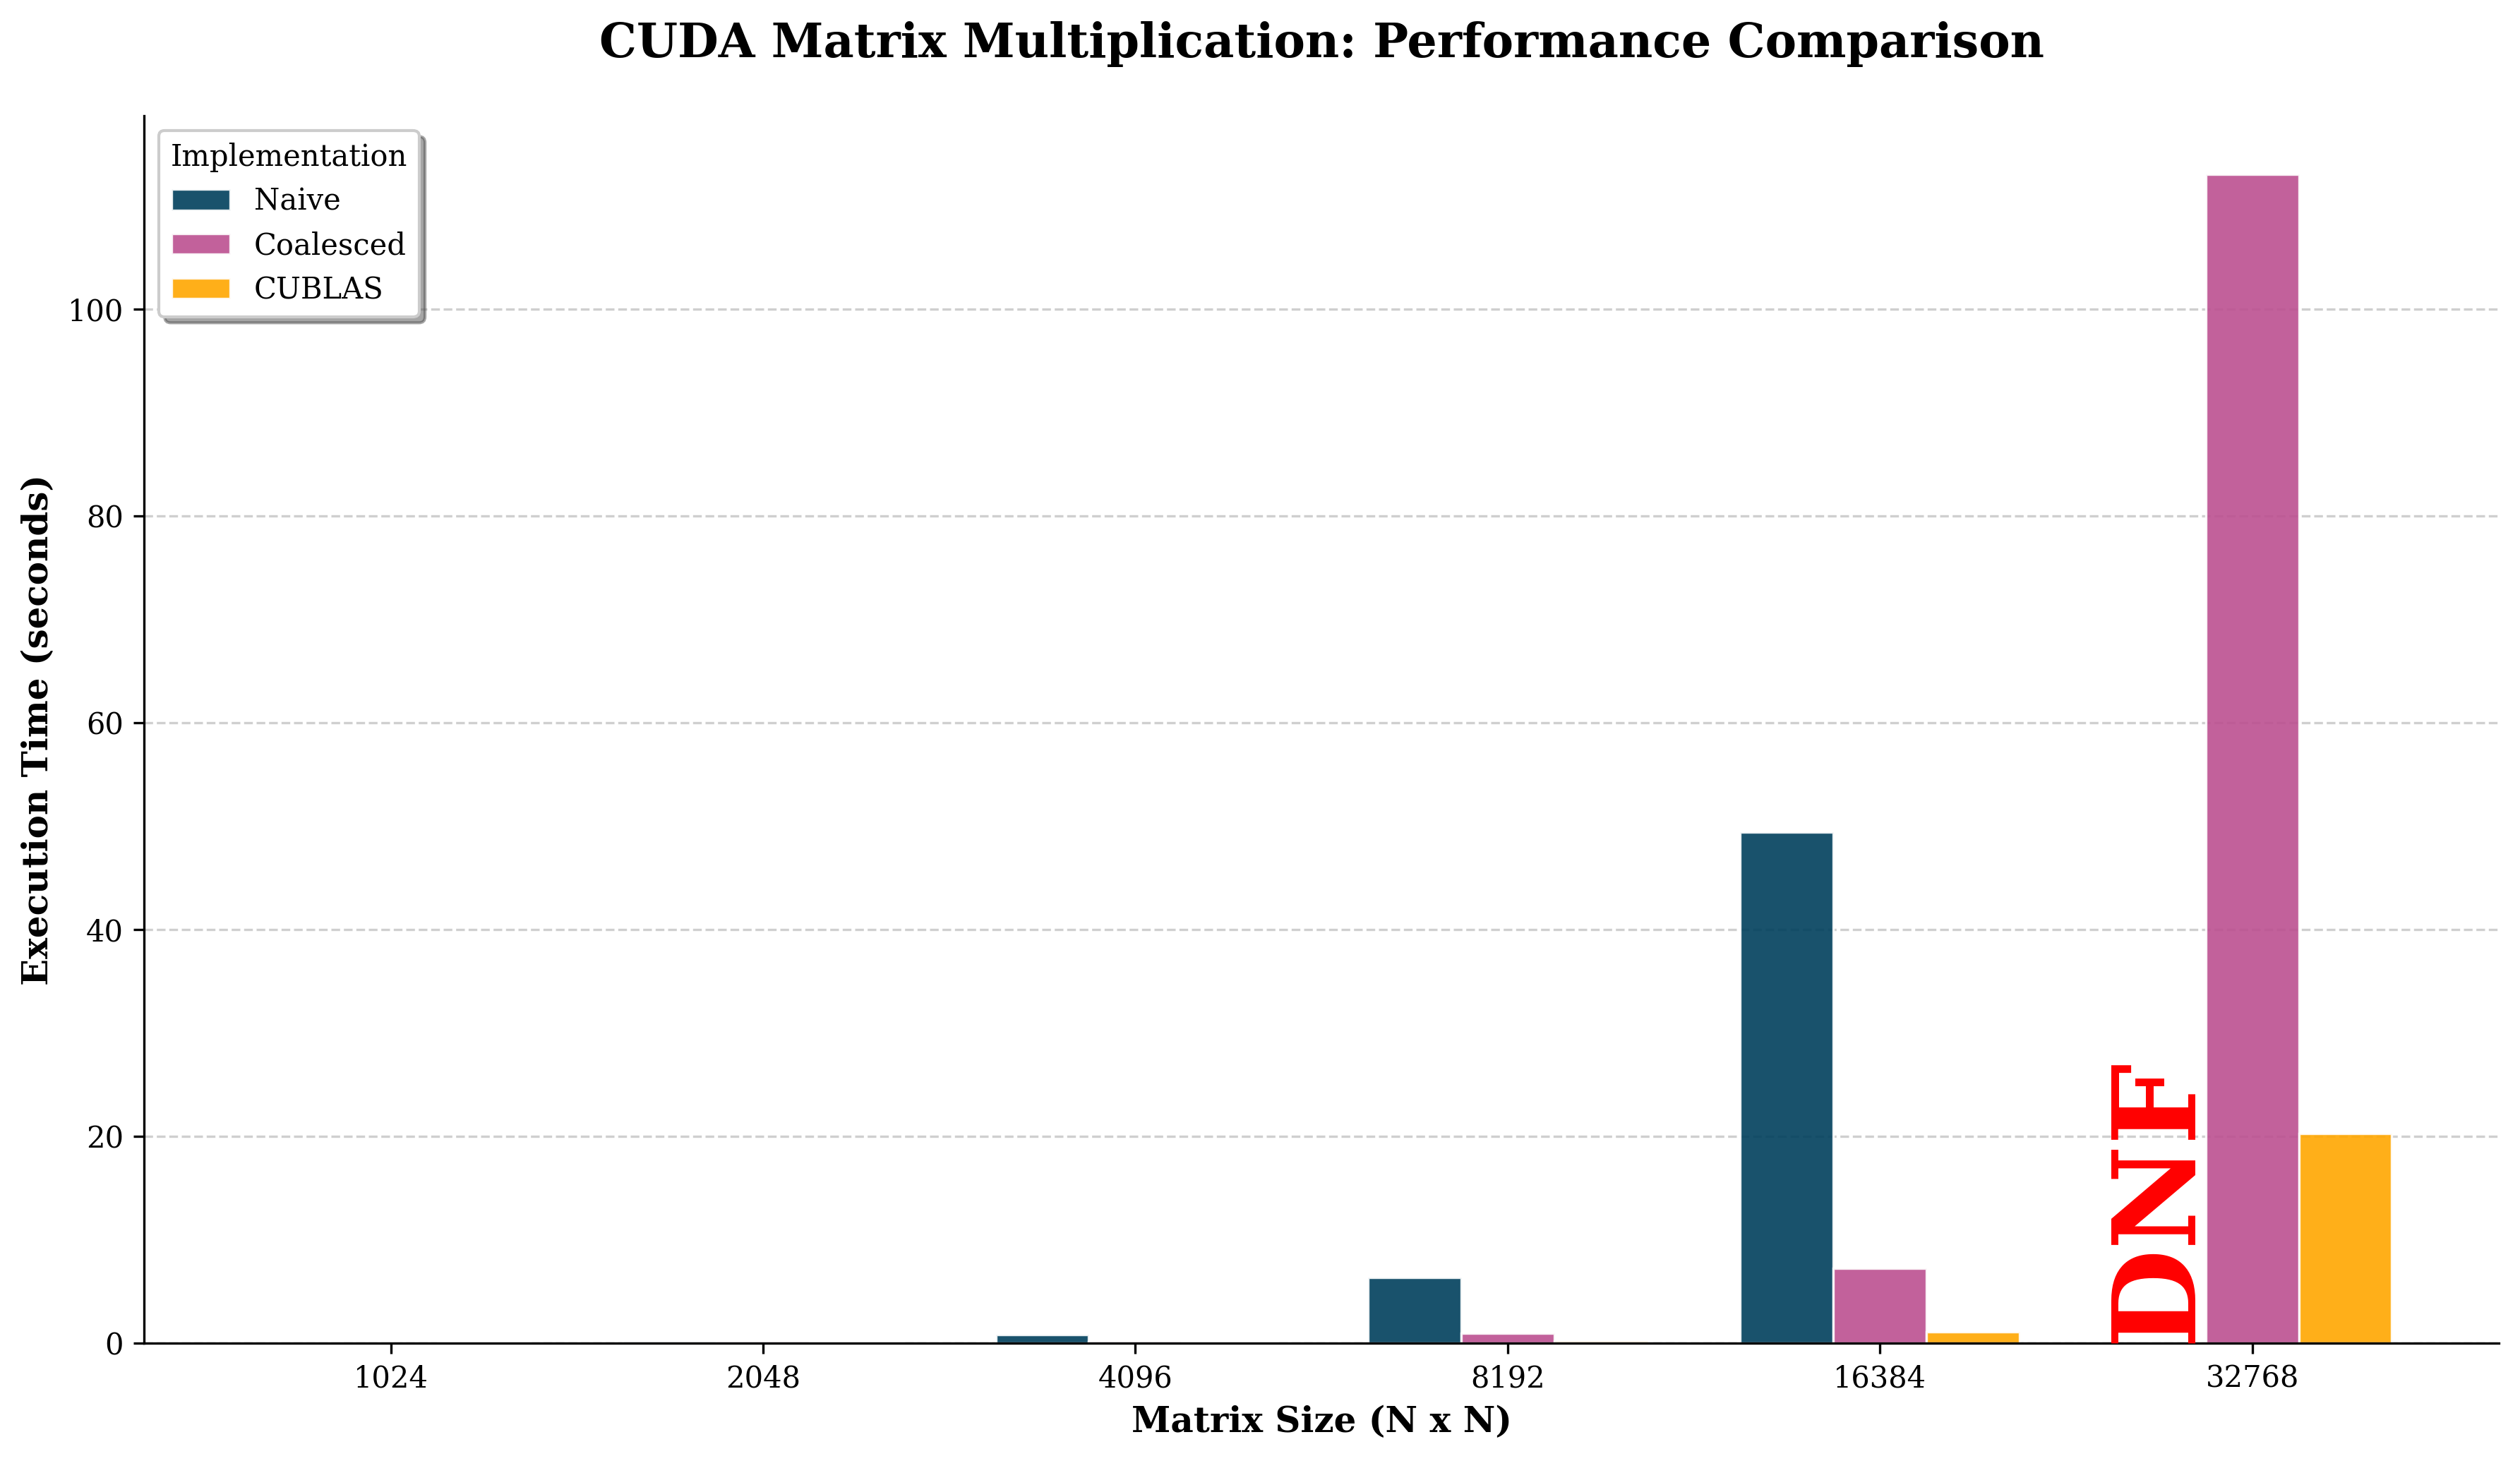

In [7]:
new_dict = {}
new_dict["Naive"] = dictionary["Naive"]
new_dict["Coalesced"] = dictionary["Coalesced"]
new_dict["CUBLAS"] = dictionary["CUBLAS"]
new_dict["Naive"][32768] = -1
plot_performance_data(new_dict, "./plots/partA-times.pdf") 

# Part B

In [8]:
generate_data("partB")
dictionary = extract_res("partB")

make: Nothing to be done for 'partB'.
Finished running for sz = 1024
Finished running for sz = 2048
Finished running for sz = 4096
Finished running for sz = 8192
Finished running for sz = 16384
Finished running for sz = 32768


In [12]:
# new_dict = {}
# new_dict["square"] = dictionary["Coalesced"]
# new_dict["row"] = dictionary["Naive"]
# new_dict["column"] = dictionary["CUBLAS"]
# new_dict["row"][32768] = -1
# plot_performance_data(new_dict, "./plots/partB-times.pdf") 
print(dictionary)

{'CPU': {1024: 2292824, 2048: 24947330}, 'Naive': {1024: 3451, 2048: 15406, 4096: 89995, 8192: 554837, 16384: 4109598, 32768: -1}, 'Coalesced': {1024: 2903771, 2048: 3100641, 4096: 640961, 8192: 1389754, 16384: 6459550, 32768: -1}, 'CUBLAS': {1024: 2750, 2048: 12327, 4096: 53333, 8192: 387382, 16384: 2748837, 32768: 37320064}}
